## 1. Imports & load data

In [36]:
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Read all CSVs
def get_whole_df() -> pd.DataFrame:
    files = sorted(glob("combined_part_*.csv"))
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df = get_whole_df()
print("Shape:", df.shape)


Shape: (692703, 79)


## 2. PreProcessing

In [37]:
# Remove Trailing whitespaces
df.columns = df.columns.str.strip()

# Remove duplicates and inf numbers
df = df.drop_duplicates()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Remove Heartbleed (low number of samples)
df = df[df["Label"] != "Heartbleed"]

print("Class Distribution:")
print(df["Label"].value_counts())


Class Distribution:
Label
BENIGN              416736
DoS Hulk            172846
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Name: count, dtype: int64


In [38]:
TOP_FEATURES = [
    "Avg Bwd Segment Size",
    "Max Packet Length",
    "Bwd Packet Length Max",
    "Packet Length Std",
    "Packet Length Mean",
    "Bwd Packet Length Mean",
    "Average Packet Size",
    "Packet Length Variance",
    "Subflow Bwd Bytes",
    "Total Length of Bwd Packets",
    "Fwd Packet Length Max",
    "Bwd Packet Length Std",
    "Init_Win_bytes_forward",
    "Flow Duration",
    "Flow Bytes/s",
    "Flow IAT Mean",
    "Fwd IAT Total",
    "Flow IAT Std",
    "Idle Mean",
    "Active Mean",
]

X = df[TOP_FEATURES]
y = df["Label"]

print(f"Use {len(TOP_FEATURES)} von {df.shape[1]-1} Features")

Use 20 von 78 Features


## 3. Train/Test-Split

In [39]:
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print("\nFeatures:", list(X_train.columns[:5]), "...")


Train: 488,384  |  Test: 122,097

Features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets'] ...


## 4. Binäre Labels erstellen (BENIGN vs. ATTACK)

In [40]:
# BENIGN stays BENIGN, everything else is ATTACK
y_train_binary = y_train.map(lambda l: "BENIGN" if l == "BENIGN" else "ATTACK")
y_test_binary  = y_test.map( lambda l: "BENIGN" if l == "BENIGN" else "ATTACK")

print("Binary Train-Distribution:")
print(y_train_binary.value_counts())


Binary Train-Distribution:
Label
BENIGN    333388
ATTACK    154996
Name: count, dtype: int64


## 5. Stage 1 – Binary Classifier (BENIGN vs. ATTACK)



=== Stage 1: BENIGN vs. ATTACK ===
Train Accuracy: 0.9876
Test  Accuracy: 0.9877

              precision    recall  f1-score   support

      ATTACK       0.98      0.98      0.98     38749
      BENIGN       0.99      0.99      0.99     83348

    accuracy                           0.99    122097
   macro avg       0.99      0.99      0.99    122097
weighted avg       0.99      0.99      0.99    122097



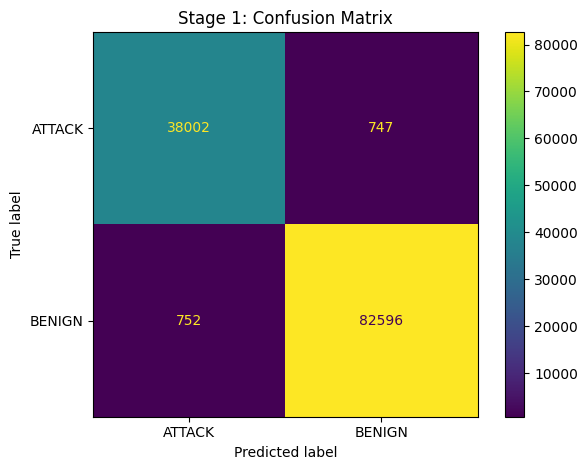

['binary_model.pkl']

In [41]:
binary_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,        # Helps against overfitting
    random_state=42,
    max_features=8, 
    min_samples_leaf=50,    
    class_weight="balanced",
    n_jobs=-1
)

binary_model.fit(X_train, y_train_binary)

pred_binary_test = binary_model.predict(X_test)
pred_binary_train = binary_model.predict(X_train)

print("=== Stage 1: BENIGN vs. ATTACK ===")
print(f"Train Accuracy: {accuracy_score(y_train_binary, pred_binary_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test_binary,  pred_binary_test):.4f}")
print()
print(classification_report(y_test_binary, pred_binary_test))

ConfusionMatrixDisplay.from_predictions(y_test_binary, pred_binary_test)
plt.title("Stage 1: Confusion Matrix")
plt.tight_layout()
plt.show()

joblib.dump(binary_model, "binary_model.pkl")


### Feature Importance (Stage 1)

In [42]:
importance = pd.Series(
    binary_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top-10 important Features:")
print(importance.head(10))


Top-10 important Features:
Avg Bwd Segment Size           0.115248
Max Packet Length              0.090948
Bwd Packet Length Max          0.084265
Packet Length Std              0.079689
Bwd Packet Length Std          0.065780
Packet Length Variance         0.064448
Average Packet Size            0.056149
Bwd Packet Length Mean         0.046834
Packet Length Mean             0.035792
Total Length of Bwd Packets    0.030793
dtype: float64


## 6. Stage 2 – Angriffs-Typ Classifier

Nur auf Attack-Zeilen trainieren. `max_depth=10` für gute Trennung
der 4 DoS-Typen ohne vollständiges Overfitting.


Attack types in training:
Label
DoS Hulk            138277
DoS GoldenEye         8229
DoS slowloris         4308
DoS Slowhttptest      4182
Name: count, dtype: int64

Nach SMOTE:
Label
DoS Hulk            138277
DoS GoldenEye       138277
DoS Slowhttptest    138277
DoS slowloris       138277
Name: count, dtype: int64

=== Stage 2: Angriffs Type (only Attack-Samples) ===
Test Accuracy: 0.9973

                  precision    recall  f1-score   support

   DoS GoldenEye       1.00      0.99      1.00      2057
        DoS Hulk       1.00      1.00      1.00     34569
DoS Slowhttptest       0.98      0.98      0.98      1046
   DoS slowloris       0.95      0.98      0.96      1077

        accuracy                           1.00     38749
       macro avg       0.98      0.99      0.98     38749
    weighted avg       1.00      1.00      1.00     38749



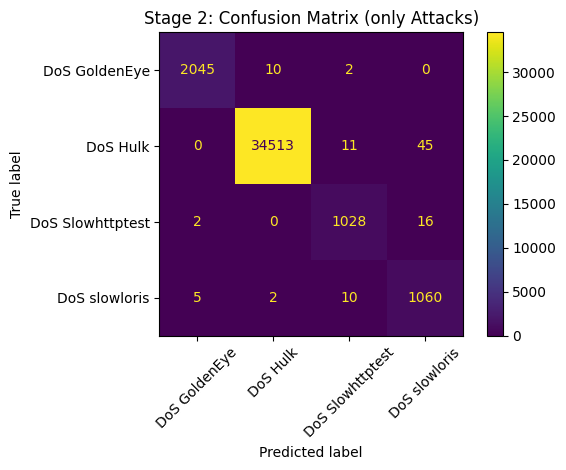

In [43]:
# Nur Angriffs-Zeilen aus den Trainingsdaten
mask_attack_train = y_train != "BENIGN"
X_train_attack = X_train[mask_attack_train]
y_train_attack = y_train[mask_attack_train]

print("Attack types in training:")
print(y_train_attack.value_counts())

target_count = y_train_attack.value_counts().iloc[1]  # DoS GoldenEye
sampling_strategy = {
    cls: max(count, target_count)
    for cls, count in y_train_attack.value_counts().items()
    if count < target_count
}
smote = SMOTE(sampling_strategy="not majority", random_state=42)
X_train_attack_res, y_train_attack_res = smote.fit_resample(X_train_attack, y_train_attack)

print("\nNach SMOTE:")
print(pd.Series(y_train_attack_res).value_counts())

attack_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,   
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

attack_model.fit(X_train_attack, y_train_attack)

mask_attack_test = y_test != "BENIGN"
X_test_attack = X_test[mask_attack_test]
y_test_attack  = y_test[mask_attack_test]

pred_attack_only = attack_model.predict(X_test_attack)

print("\n=== Stage 2: Angriffs Type (only Attack-Samples) ===")
print(f"Test Accuracy: {accuracy_score(y_test_attack, pred_attack_only):.4f}")
print()
print(classification_report(y_test_attack, pred_attack_only))

ConfusionMatrixDisplay.from_predictions(y_test_attack, pred_attack_only)
plt.title("Stage 2: Confusion Matrix (only Attacks)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Zweistufige Pipeline – kombinierte Evaluation

Stage 1 entscheidet BENIGN/ATTACK → nur ATTACK-Samples gehen in Stage 2.
Vektoriell (kein langsamer Row-by-Row-Loop).


=== Zweistufiges System – Gesamtergebnis ===
Overall-Accuracy: 0.9871

                  precision    recall  f1-score   support

          BENIGN       0.99      0.99      0.99     83348
   DoS GoldenEye       0.98      0.91      0.95      2057
        DoS Hulk       0.99      0.99      0.99     34569
DoS Slowhttptest       0.96      0.85      0.90      1046
   DoS slowloris       0.67      0.90      0.76      1077

        accuracy                           0.99    122097
       macro avg       0.92      0.93      0.92    122097
    weighted avg       0.99      0.99      0.99    122097



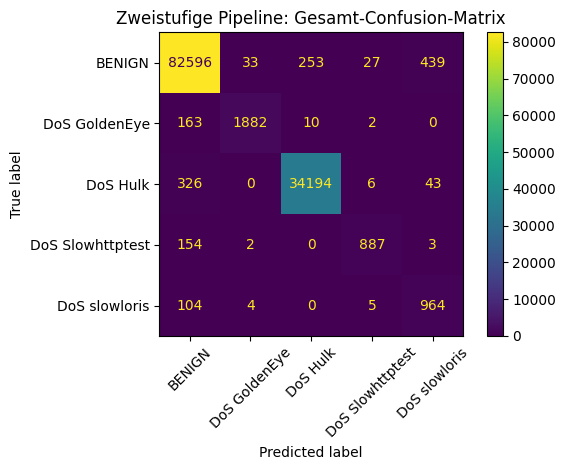

['attack_model.pkl']

In [44]:
stage1_pred = binary_model.predict(X_test)

final_predictions = pd.Series(stage1_pred, index=X_test.index)

attack_idx = X_test.index[stage1_pred == "ATTACK"]
if len(attack_idx) > 0:
    stage2_pred = attack_model.predict(X_test.loc[attack_idx])
    final_predictions.loc[attack_idx] = stage2_pred

print("=== Zweistufiges System – Gesamtergebnis ===")
print(f"Overall-Accuracy: {accuracy_score(y_test, final_predictions):.4f}")
print()
print(classification_report(y_test, final_predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test, final_predictions,
    xticks_rotation=45
)
plt.title("Zweistufige Pipeline: Gesamt-Confusion-Matrix")
plt.tight_layout()
plt.show()

joblib.dump(attack_model, "attack_model.pkl")